In [ ]:
"""Importing Libraries"""

#General
import pandas as pd
import numpy as np
import scipy
import scipy.io
import os
import zipfile
import matplotlib.pyplot as plt
from scipy import signal
import librosa

#Deep Learning
import imgaug.augmenters as iaa
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.layers import Input, Conv2D, Conv1D, MaxPooling1D, BatchNormalization, Dense, MaxPooling2D, Flatten, Dense, Dropout, concatenate, LSTM, Reshape, Concatenate, Activation, Permute, Multiply
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
import seaborn as sns

from sklearn.svm import SVC

import gc

In [ ]:
"""Mounting Google Drive"""
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [ ]:
import pickle

filename = "/content/drive/MyDrive/Meta Learning - New Project/Features_DSR.pkl"

# Load data from the pickle file
with open(filename, 'rb') as file:
    loaded_data = pickle.load(file)


eeg_data = loaded_data["Features_EEG_Reshaped"]
nirs_data = loaded_data["NIRS_All_Participants"]
labels = loaded_data["Labels_All_Participnats"]

In [ ]:
Features_EEG_Reshaped = eeg_data[0:200, :, :]
NIRS_All_Participants = nirs_data[0:200, :, :]
Labels_All_Participnats = labels[0:200]

In [ ]:
# Features_EEG_Reshaped = Features_EEG_Reshaped[0:200, :, :]
# NIRS_All_Participants = NIRS_All_Participants[0:200, :, :]
# Labels_All_Participnats = Labels_All_Participnats[0:200]

In [ ]:
def DataAugmentation(Data, Labels):
  # Define the augmentation pipeline
  augmentation = iaa.Sequential([
    iaa.Flipud(p=0.005),                   # Flip images vertically
    iaa.Affine(rotate=(-1, 1)),       # Rotate images within the range -10 to 10 degrees
    iaa.AdditiveGaussianNoise(scale=(0, 0.005)),  # Add Gaussian noise
])

  # Create empty lists to store augmented features and labels
  augmented_features = []
  augmented_labels = []

  # Augment the data
  for i in range(len(Data)):
      feature = Data[i]
      label = Labels[i]

      # Apply augmentation to the feature
      augmented_feature = augmentation.augment_image(feature)

      # Add the augmented feature and corresponding label to the lists
      augmented_features.append(augmented_feature)
      augmented_labels.append(label)

      # Apply additional augmentation to generate more samples if needed
      for _ in range(100):  # Adjust the number of additional samples as desired
          augmented_feature = augmentation.augment_image(feature)
          augmented_features.append(augmented_feature)
          augmented_labels.append(label)

  # Convert the augmented features and labels lists to NumPy arrays
  augmented_features = np.array(augmented_features)
  augmented_labels = np.array(augmented_labels)

  # Check the shape of the augmented data
  print(augmented_features.shape)
  print(augmented_labels.shape)

  return augmented_features, augmented_labels

In [ ]:
def Predictions_Scores(model, test_data, test_labels, save_name):
  predictions = model.predict(test_data)

  # Convert the predictions to class labels
  predicted_labels = np.argmax(predictions, axis=1)
  labels_test_updated = np.argmax(test_labels, axis=-1)

  cf_matrix = confusion_matrix(labels_test_updated, predicted_labels)
  plt.figure()
  labels = ['Discrimination', 'Selection']
  ax = sns.heatmap(cf_matrix, annot=True, cmap='Blues', fmt='d',
                 xticklabels=labels, yticklabels=labels)
  ax.set_xlabel('\nPredicted Values')
  ax.set_ylabel('Actual Values ')
  ## Display the visualization of the Confusion Matrix.
  save_path = '/' + save_name
  plt.savefig(save_path + '.eps', format='eps', bbox_inches='tight')
  plt.savefig(save_path + '.pdf', format='pdf', bbox_inches='tight')
  plt.show()
  accuracy = accuracy_score(labels_test_updated, predicted_labels)
  precision = precision_score(labels_test_updated, predicted_labels, average='macro')
  recall = recall_score(labels_test_updated, predicted_labels, average='macro')
  f1 = f1_score(labels_test_updated, predicted_labels,average='macro')

  print('Accuracy: %.3f' % accuracy_score(labels_test_updated, predicted_labels))
  print('Precision: %.3f' % precision_score(labels_test_updated, predicted_labels, average='macro'))
  print('Recall: %.3f' % recall_score(labels_test_updated, predicted_labels, average='macro'))
  print('F1 Score: %.3f' % f1_score(labels_test_updated, predicted_labels,average='macro'))

  return accuracy, precision, recall, f1


In [ ]:
def custom_loss(class_weights, asymmetric_weights, regularization_factor):
    class_weights = tf.convert_to_tensor(class_weights, dtype=tf.float32)
    asymmetric_weights = tf.convert_to_tensor(asymmetric_weights, dtype=tf.float32)

    def loss_function(y_true, y_pred):
        # Calculate weighted cross-entropy loss
        weighted_losses = tf.nn.weighted_cross_entropy_with_logits(y_true, y_pred, pos_weight=class_weights)

        # Apply asymmetric loss terms
        asymmetric_losses = tf.where(tf.equal(y_true, 1), asymmetric_weights * weighted_losses, weighted_losses)

        # Total loss
        total_loss = tf.reduce_mean(asymmetric_losses)

        # Regularization term (encouraging smoothness)
        regularization_loss = tf.reduce_mean(tf.abs(y_pred[:, 1:] - y_pred[:, :-1]))

        # Combine losses
        total_loss += regularization_factor * regularization_loss

        return total_loss

    return loss_function

In [ ]:
def tcn_layer(input_layer, num_filters=64, kernel_size=3, dilation_rate=1):
    conv = Conv1D(filters=num_filters, kernel_size=kernel_size, dilation_rate=dilation_rate, padding='causal', activation='relu')(input_layer)
    conv = BatchNormalization()(conv)  # Adding batch normalization
    return conv

def temporal_attention(input_layer):
    x = Permute((2, 1))(input_layer)
    x = Dense(1, activation='tanh')(x)
    x = Permute((2, 1))(x)
    x = Multiply()([input_layer, x])
    x = Activation('softmax')(x)
    return x

def CNN_EEG_NIRS_Testing(eeg_train, eeg_test, nirs_train, nirs_test, labels_train, labels_test):
    eeg_input_shape = np.shape(eeg_train)[1], np.shape(eeg_train)[2]
    nirs_input_shape = np.shape(nirs_train)[1], np.shape(nirs_train)[2]

    eeg_input = Input(shape=eeg_input_shape, name='eeg_input')
    eeg_tcn = tcn_layer(eeg_input)
    eeg_attention = temporal_attention(eeg_tcn)
    eeg_lstm = LSTM(64, return_sequences=True)(eeg_attention)
    eeg_flatten = Flatten()(eeg_lstm)

    nirs_input = Input(shape=nirs_input_shape, name='nirs_input')
    nirs_tcn = tcn_layer(nirs_input)
    nirs_attention = temporal_attention(nirs_tcn)
    nirs_lstm = LSTM(64, return_sequences=True)(nirs_attention)
    nirs_flatten = Flatten()(nirs_lstm)

    concatenated = Concatenate()([eeg_flatten, nirs_flatten])

    dense1 = Dense(32, activation='relu')(concatenated)
    # dense1 = BatchNormalization()(dense1)  # Adding batch normalization
    # dense1 = Dropout(0.5)(dense1)  # Adding dropout for regularization
    dense2 = Dense(32, activation='relu')(dense1)

    output = Dense(2, activation='sigmoid')(dense2)

    model = Model(inputs=[eeg_input, nirs_input], outputs=output)

    lr = 1e-4
    optimizer = Adam(lr=lr)
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    # model.compile(loss=custom_loss(class_weights=[1, 1], asymmetric_weights=[1, 2], regularization_factor=0.0001), optimizer=optimizer, metrics=['accuracy'])

    return model

In [ ]:
EEG_augmented_features, augmented_labels = DataAugmentation(Features_EEG_Reshaped, Labels_All_Participnats)
# EEG_augmented_features = (EEG_augmented_features - np.min(EEG_augmented_features)) / (np.max(EEG_augmented_features) - np.min(EEG_augmented_features))
EEG_augmented_features = EEG_augmented_features / np.max(EEG_augmented_features)

NIRS_augmented_features, augmented_labels = DataAugmentation(NIRS_All_Participants, Labels_All_Participnats)
# NIRS_augmented_features = (NIRS_augmented_features - np.mean(NIRS_augmented_features)) / np.std(NIRS_augmented_features)
NIRS_augmented_features = NIRS_augmented_features / np.max(NIRS_augmented_features)

onehot_encoder = OneHotEncoder(sparse=False)
Labels_Encoded = augmented_labels.reshape(len(augmented_labels), 1)
Labels_Encoded = onehot_encoder.fit_transform(Labels_Encoded)

eeg_train, eeg_test, nirs_train, nirs_test, labels_train, labels_test = train_test_split(
      EEG_augmented_features, NIRS_augmented_features, Labels_Encoded, test_size=0.1, random_state=42)

model = CNN_EEG_NIRS_Testing(eeg_train, eeg_test, nirs_train, nirs_test, labels_train, labels_test)

from tensorflow.keras.callbacks import ModelCheckpoint
checkpoint = ModelCheckpoint("best_model.h5", monitor="val_accuracy", save_best_only=True, mode="max", verbose=1)

history = model.fit([eeg_train, nirs_train], labels_train, epochs=300, batch_size=64, validation_split=0.2, callbacks=[checkpoint])

(20200, 12, 360)
(20200,)
(20200, 19, 72)
(20200,)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Epoch 1/300
228/228 [==============================] - ETA: 0s - loss: 0.6057 - accuracy: 0.6977
Epoch 1: val_accuracy improved from -inf to 0.70545, saving model to best_model.h5
228/228 [==============================] - 15s 24ms/step - loss: 0.6057 - accuracy: 0.6977 - val_loss: 0.5892 - val_accuracy: 0.7054
Epoch 2/300
 11/228 [>.............................] - ETA: 2s - loss: 0.5477 - accuracy: 0.7088

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


225/228 [============================>.] - ETA: 0s - loss: 0.4183 - accuracy: 0.8022
Epoch 2: val_accuracy improved from 0.70545 to 0.74147, saving model to best_model.h5
228/228 [==============================] - 3s 12ms/step - loss: 0.4186 - accuracy: 0.8014 - val_loss: 0.5072 - val_accuracy: 0.7415
Epoch 3/300
224/228 [============================>.] - ETA: 0s - loss: 0.2136 - accuracy: 0.9142
Epoch 3: val_accuracy improved from 0.74147 to 0.88971, saving model to best_model.h5
228/228 [==============================] - 3s 12ms/step - loss: 0.2129 - accuracy: 0.9144 - val_loss: 0.2642 - val_accuracy: 0.8897
Epoch 4/300
227/228 [============================>.] - ETA: 0s - loss: 0.0979 - accuracy: 0.9648
Epoch 4: val_accuracy improved from 0.88971 to 0.93344, saving model to best_model.h5
228/228 [==============================] - 3s 13ms/step - loss: 0.0980 - accuracy: 0.9648 - val_loss: 0.1555 - val_accuracy: 0.9334
Epoch 5/300
227/228 [============================>.] - ETA: 0s - lo

64/64 [==============================] - 1s 5ms/step


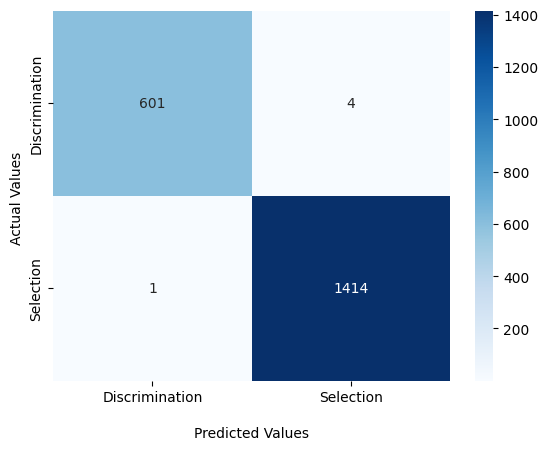

Accuracy: 0.998
Precision: 0.998
Recall: 0.996
F1 Score: 0.997


(0.9975247524752475,
 0.9977589979804038,
 0.9963408579855737,
 0.9970462922047556)

In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model('best_model.h5', custom_objects={'loss_function': custom_loss})

# filepath = "/content/drive/MyDrive/BestModel_NBACK.h5"

# best_model.save(filepath)

Predictions_Scores(best_model, [eeg_test, nirs_test], labels_test, 'DSR_TAFN')

In [ ]:
def DataAugmentation(Data, Labels):
  # Define the augmentation pipeline
  augmentation = iaa.Sequential([
    iaa.Flipud(p=0.005),                   # Flip images vertically
    iaa.Affine(rotate=(-1, 1)),       # Rotate images within the range -10 to 10 degrees
    iaa.AdditiveGaussianNoise(scale=(0, 0.005)),  # Add Gaussian noise
])

  # Create empty lists to store augmented features and labels
  augmented_features = []
  augmented_labels = []

  # Augment the data
  for i in range(len(Data)):
      feature = Data[i]
      label = Labels[i]

      # Apply augmentation to the feature
      augmented_feature = augmentation.augment_image(feature)

      # Add the augmented feature and corresponding label to the lists
      augmented_features.append(augmented_feature)
      augmented_labels.append(label)

      # Apply additional augmentation to generate more samples if needed
      for _ in range(1):  # Adjust the number of additional samples as desired
          augmented_feature = augmentation.augment_image(feature)
          augmented_features.append(augmented_feature)
          augmented_labels.append(label)

  # Convert the augmented features and labels lists to NumPy arrays
  augmented_features = np.array(augmented_features)
  augmented_labels = np.array(augmented_labels)

  # Check the shape of the augmented data
  print(augmented_features.shape)
  print(augmented_labels.shape)

  return augmented_features, augmented_labels

(400, 12, 360)
(400,)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


(400, 19, 72)
(400,)
Epoch 1/300
5/5 [==============================] - ETA: 0s - loss: 1.0963 - accuracy: 0.4722 
Epoch 1: val_accuracy improved from -inf to 0.52778, saving model to best_model.h5
5/5 [==============================] - 3s 105ms/step - loss: 1.0963 - accuracy: 0.4722 - val_loss: 0.9671 - val_accuracy: 0.5278
Epoch 2/300
1/5 [=====>........................] - ETA: 0s - loss: 0.9192 - accuracy: 0.7188
Epoch 2: val_accuracy improved from 0.52778 to 0.58333, saving model to best_model.h5
5/5 [==============================] - 0s 29ms/step - loss: 0.7131 - accuracy: 0.6736 - val_loss: 0.7473 - val_accuracy: 0.5833
Epoch 3/300
1/5 [=====>........................] - ETA: 0s - loss: 0.5716 - accuracy: 0.7031

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



Epoch 3: val_accuracy improved from 0.58333 to 0.66667, saving model to best_model.h5
5/5 [==============================] - 0s 33ms/step - loss: 0.5720 - accuracy: 0.7118 - val_loss: 0.6838 - val_accuracy: 0.6667
Epoch 4/300
1/5 [=====>........................] - ETA: 0s - loss: 0.6391 - accuracy: 0.6562
Epoch 4: val_accuracy improved from 0.66667 to 0.68056, saving model to best_model.h5
5/5 [==============================] - 0s 25ms/step - loss: 0.5412 - accuracy: 0.7292 - val_loss: 0.6606 - val_accuracy: 0.6806
Epoch 5/300
1/5 [=====>........................] - ETA: 0s - loss: 0.4536 - accuracy: 0.7969
Epoch 5: val_accuracy did not improve from 0.68056
5/5 [==============================] - 0s 16ms/step - loss: 0.5074 - accuracy: 0.7431 - val_loss: 0.6490 - val_accuracy: 0.6806
Epoch 6/300
1/5 [=====>........................] - ETA: 0s - loss: 0.4254 - accuracy: 0.8438
Epoch 6: val_accuracy did not improve from 0.68056
5/5 [==============================] - 0s 13ms/step - loss: 0.

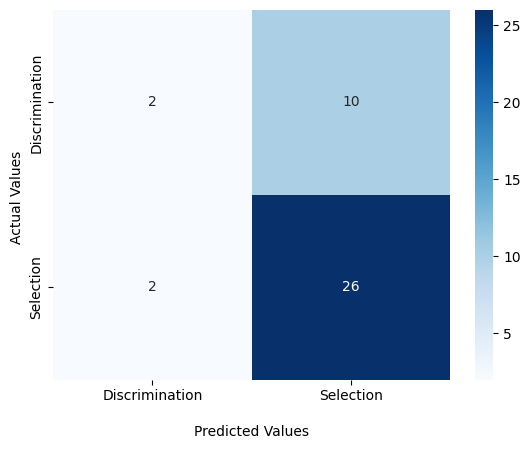

Accuracy: 0.700
Precision: 0.611
Recall: 0.548
F1 Score: 0.531


(0.7, 0.6111111111111112, 0.5476190476190477, 0.53125)

In [ ]:
from keras.models import Model
from keras.layers import Input, Conv1D, BatchNormalization, Flatten, Dense, Concatenate
from keras.optimizers import Adam
import numpy as np

def CNN_model(eeg_train, eeg_test, nirs_train, nirs_test, labels_train, labels_test):
    eeg_input_shape = np.shape(eeg_train)[1], np.shape(eeg_train)[2]
    nirs_input_shape = np.shape(nirs_train)[1], np.shape(nirs_train)[2]

    eeg_input = Input(shape=eeg_input_shape, name='eeg_input')
    eeg_conv = Conv1D(64, kernel_size=3, activation='relu', padding='same')(eeg_input)
    eeg_bn = BatchNormalization()(eeg_conv)
    eeg_flatten = Flatten()(eeg_bn)

    nirs_input = Input(shape=nirs_input_shape, name='nirs_input')
    nirs_conv = Conv1D(64, kernel_size=3, activation='relu', padding='same')(nirs_input)
    nirs_bn = BatchNormalization()(nirs_conv)
    nirs_flatten = Flatten()(nirs_bn)

    concatenated = Concatenate()([eeg_flatten, nirs_flatten])

    dense1 = Dense(32, activation='relu')(concatenated)
    dense2 = Dense(32, activation='relu')(dense1)
    output = Dense(2, activation='sigmoid')(dense2)

    model = Model(inputs=[eeg_input, nirs_input], outputs=output)

    optimizer = Adam(lr=1e-4)
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    return model


EEG_augmented_features, augmented_labels = DataAugmentation(Features_EEG_Reshaped, Labels_All_Participnats)
# EEG_augmented_features = (EEG_augmented_features - np.min(EEG_augmented_features)) / (np.max(EEG_augmented_features) - np.min(EEG_augmented_features))
EEG_augmented_features = EEG_augmented_features / np.max(EEG_augmented_features)

NIRS_augmented_features, augmented_labels = DataAugmentation(NIRS_All_Participants, Labels_All_Participnats)
# NIRS_augmented_features = (NIRS_augmented_features - np.mean(NIRS_augmented_features)) / np.std(NIRS_augmented_features)
NIRS_augmented_features = NIRS_augmented_features / np.max(NIRS_augmented_features)

onehot_encoder = OneHotEncoder(sparse=False)
Labels_Encoded = augmented_labels.reshape(len(augmented_labels), 1)
Labels_Encoded = onehot_encoder.fit_transform(Labels_Encoded)

eeg_train, eeg_test, nirs_train, nirs_test, labels_train, labels_test = train_test_split(
      EEG_augmented_features, NIRS_augmented_features, Labels_Encoded, test_size=0.1, random_state=42)


model = CNN_model(eeg_train, eeg_test, nirs_train, nirs_test, labels_train, labels_test)

from tensorflow.keras.callbacks import ModelCheckpoint
checkpoint = ModelCheckpoint("best_model.h5", monitor="val_accuracy", save_best_only=True, mode="max", verbose=1)

history = model.fit([eeg_train, nirs_train], labels_train, epochs=300, batch_size=64, validation_split=0.2, callbacks=[checkpoint])

best_model = load_model('best_model.h5', custom_objects={'loss_function': custom_loss})

Predictions_Scores(best_model, [eeg_test, nirs_test], labels_test, 'DSR_CNN')

Epoch 1/300
1/5 [=====>........................] - ETA: 14s - loss: 0.8107 - accuracy: 0.3750
Epoch 1: val_accuracy improved from -inf to 0.72222, saving model to best_model.h5
5/5 [==============================] - 4s 215ms/step - loss: 0.7661 - accuracy: 0.3993 - val_loss: 0.6239 - val_accuracy: 0.7222
Epoch 2/300
1/5 [=====>........................] - ETA: 0s - loss: 0.5634 - accuracy: 0.8125
Epoch 2: val_accuracy improved from 0.72222 to 0.77778, saving model to best_model.h5
5/5 [==============================] - 0s 25ms/step - loss: 0.5000 - accuracy: 0.8507 - val_loss: 0.5337 - val_accuracy: 0.7778
Epoch 3/300
1/5 [=====>........................] - ETA: 0s - loss: 0.3902 - accuracy: 0.8750

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



Epoch 3: val_accuracy did not improve from 0.77778
5/5 [==============================] - 0s 19ms/step - loss: 0.3791 - accuracy: 0.8854 - val_loss: 0.4877 - val_accuracy: 0.7639
Epoch 4/300
1/5 [=====>........................] - ETA: 0s - loss: 0.3083 - accuracy: 0.9219
Epoch 4: val_accuracy improved from 0.77778 to 0.80556, saving model to best_model.h5
5/5 [==============================] - 0s 24ms/step - loss: 0.2754 - accuracy: 0.9410 - val_loss: 0.4421 - val_accuracy: 0.8056
Epoch 5/300
1/5 [=====>........................] - ETA: 0s - loss: 0.2334 - accuracy: 0.9844
Epoch 5: val_accuracy improved from 0.80556 to 0.81944, saving model to best_model.h5
5/5 [==============================] - 0s 25ms/step - loss: 0.1975 - accuracy: 0.9896 - val_loss: 0.4088 - val_accuracy: 0.8194
Epoch 6/300
1/5 [=====>........................] - ETA: 0s - loss: 0.1472 - accuracy: 0.9844
Epoch 6: val_accuracy did not improve from 0.81944
5/5 [==============================] - 0s 23ms/step - loss: 0.

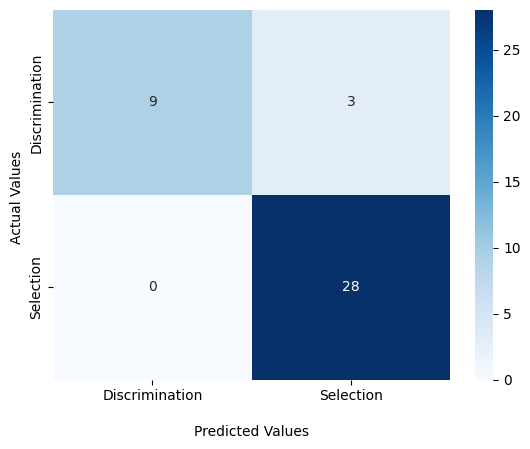

Accuracy: 0.925
Precision: 0.952
Recall: 0.875
F1 Score: 0.903


(0.925, 0.9516129032258065, 0.875, 0.9031476997578691)

In [ ]:
from keras.models import Model
from keras.layers import Input, LSTM, Flatten, Dense, Concatenate
from keras.optimizers import Adam
import numpy as np

def LSTM_model(eeg_train, eeg_test, nirs_train, nirs_test, labels_train, labels_test):
    eeg_input_shape = np.shape(eeg_train)[1], np.shape(eeg_train)[2]
    nirs_input_shape = np.shape(nirs_train)[1], np.shape(nirs_train)[2]

    eeg_input = Input(shape=eeg_input_shape, name='eeg_input')
    eeg_lstm = LSTM(64, return_sequences=True)(eeg_input)
    eeg_flatten = Flatten()(eeg_lstm)

    nirs_input = Input(shape=nirs_input_shape, name='nirs_input')
    nirs_lstm = LSTM(64, return_sequences=True)(nirs_input)
    nirs_flatten = Flatten()(nirs_lstm)

    concatenated = Concatenate()([eeg_flatten, nirs_flatten])

    dense1 = Dense(32, activation='relu')(concatenated)
    dense2 = Dense(32, activation='relu')(dense1)
    output = Dense(2, activation='sigmoid')(dense2)

    model = Model(inputs=[eeg_input, nirs_input], outputs=output)

    optimizer = Adam(lr=1e-4)
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    return model

model = LSTM_model(eeg_train, eeg_test, nirs_train, nirs_test, labels_train, labels_test)

from tensorflow.keras.callbacks import ModelCheckpoint
checkpoint = ModelCheckpoint("best_model.h5", monitor="val_accuracy", save_best_only=True, mode="max", verbose=1)

history = model.fit([eeg_train, nirs_train], labels_train, epochs=300, batch_size=64, validation_split=0.2, callbacks=[checkpoint])

best_model = load_model('best_model.h5', custom_objects={'loss_function': custom_loss})

Predictions_Scores(best_model, [eeg_test, nirs_test], labels_test, 'DSR_LSTM')

Epoch 1/300
1/5 [=====>........................] - ETA: 19s - loss: 0.7012 - accuracy: 0.4219
Epoch 1: val_accuracy improved from -inf to 0.56944, saving model to best_model.h5
5/5 [==============================] - 6s 225ms/step - loss: 0.6685 - accuracy: 0.6285 - val_loss: 0.6870 - val_accuracy: 0.5694
Epoch 2/300
1/5 [=====>........................] - ETA: 0s - loss: 0.6914 - accuracy: 0.5938
Epoch 2: val_accuracy improved from 0.56944 to 0.65278, saving model to best_model.h5


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


5/5 [==============================] - 0s 33ms/step - loss: 0.6139 - accuracy: 0.7083 - val_loss: 0.6698 - val_accuracy: 0.6528
Epoch 3/300
1/5 [=====>........................] - ETA: 0s - loss: 0.5438 - accuracy: 0.7812
Epoch 3: val_accuracy did not improve from 0.65278
5/5 [==============================] - 0s 20ms/step - loss: 0.6063 - accuracy: 0.7049 - val_loss: 0.6577 - val_accuracy: 0.6528
Epoch 4/300
1/5 [=====>........................] - ETA: 0s - loss: 0.6352 - accuracy: 0.6562
Epoch 4: val_accuracy improved from 0.65278 to 0.68056, saving model to best_model.h5
5/5 [==============================] - 0s 32ms/step - loss: 0.5792 - accuracy: 0.7153 - val_loss: 0.6570 - val_accuracy: 0.6806
Epoch 5/300
1/5 [=====>........................] - ETA: 0s - loss: 0.5987 - accuracy: 0.6719
Epoch 5: val_accuracy did not improve from 0.68056
5/5 [==============================] - 0s 22ms/step - loss: 0.5743 - accuracy: 0.7188 - val_loss: 0.6457 - val_accuracy: 0.6806
Epoch 6/300
1/5 [====

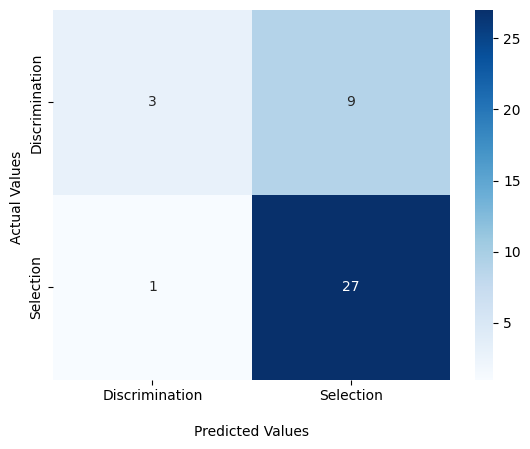

Accuracy: 0.750
Precision: 0.750
Recall: 0.607
F1 Score: 0.609


(0.75, 0.75, 0.6071428571428572, 0.609375)

In [ ]:
from keras.models import Model
from keras.layers import Input, Conv1D, LSTM, BatchNormalization, Flatten, Dense, Concatenate
from keras.optimizers import Adam
import numpy as np

def CNN_LSTM_model(eeg_train, eeg_test, nirs_train, nirs_test, labels_train, labels_test):
    eeg_input_shape = np.shape(eeg_train)[1], np.shape(eeg_train)[2]
    nirs_input_shape = np.shape(nirs_train)[1], np.shape(nirs_train)[2]

    eeg_input = Input(shape=eeg_input_shape, name='eeg_input')
    eeg_conv = Conv1D(64, kernel_size=3, activation='relu', padding='same')(eeg_input)
    eeg_bn = BatchNormalization()(eeg_conv)
    eeg_lstm = LSTM(64, return_sequences=True)(eeg_bn)
    eeg_flatten = Flatten()(eeg_lstm)

    nirs_input = Input(shape=nirs_input_shape, name='nirs_input')
    nirs_conv = Conv1D(64, kernel_size=3, activation='relu', padding='same')(nirs_input)
    nirs_bn = BatchNormalization()(nirs_conv)
    nirs_lstm = LSTM(64, return_sequences=True)(nirs_bn)
    nirs_flatten = Flatten()(nirs_lstm)

    concatenated = Concatenate()([eeg_flatten, nirs_flatten])

    dense1 = Dense(32, activation='relu')(concatenated)
    dense2 = Dense(32, activation='relu')(dense1)
    output = Dense(2, activation='sigmoid')(dense2)

    model = Model(inputs=[eeg_input, nirs_input], outputs=output)

    optimizer = Adam(lr=1e-4)
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    return model

model = CNN_LSTM_model(eeg_train, eeg_test, nirs_train, nirs_test, labels_train, labels_test)

from tensorflow.keras.callbacks import ModelCheckpoint
checkpoint = ModelCheckpoint("best_model.h5", monitor="val_accuracy", save_best_only=True, mode="max", verbose=1)

history = model.fit([eeg_train, nirs_train], labels_train, epochs=300, batch_size=64, validation_split=0.2, callbacks=[checkpoint])

best_model = load_model('best_model.h5', custom_objects={'loss_function': custom_loss})

Predictions_Scores(best_model, [eeg_test, nirs_test], labels_test, 'DSR_CNN_LSTM')